# Viscoelastic wave propagator with Maxwell - GSLS formulation #

This tutorial was prepared by Paula Neves de Araujo (paulan@ime.usp.br).

This tutorial is an introduction to the viscoelastic wave propagator of Spyro using the Maxwell - GSLS formulation.

First, the notebook environment is configured and the required modules are imported. If you are running this notebook in Google colab, please copy the following code into a code block before running the notebook:

```python
# For use in colab only:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

!pip install git+https://github.com/NDF-Poli-USP/spyro.git

In [1]:
%matplotlib inline
import spyro
import numpy as np

from firedrake import *

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


We define some basic parameters for the simulation:

In [2]:
source_location = (-500.0, 500.0)

receiver_location = spyro.create_transect(
    (-450.0,  50.0),
    (-450.0,  950.0),
    300
)

dx_target = 10 
dt = 0.0005
final_time = 0.4
frequency = 10.0
omega0 = 2.0 * np.pi * frequency

domain_size = 1000.0 

rho = 2000.0
vp = 2500.0
vs = vp / 1.732
mu = rho * vs**2
lmbda = rho * (vp**2 - 2 * vs**2)

amplitude = np.array([0.0, 5e7])

fmin = 1e-1
fmax = 3 * frequency
L = 5
nf = 100

The following dictionary is constructed to provide the problem parameters:

In [3]:
base_dictionary = {
    "options": {
        "cell_type": "T",
        "variant": "lumped",
        "degree": 2,
        "dimension": 2,
    },
    "wave_type": 'isotropic',
    "parallelism": {"type": "automatic"},
    "mesh": {
        "length_z": domain_size,
        "length_x": domain_size,
        "mesh_file": None,
        "mesh_type": "firedrake_mesh",
    },
    "acquisition": {
        "source_type": "ricker",
        "source_locations": [source_location],
        "frequency": frequency,
        "delay": 0.2,
        "delay_type": "time",
        "receiver_locations": receiver_location,
        "amplitude": amplitude,
    },
    "time_axis": {
        "initial_time": 0.0,
        "final_time": final_time,
        "dt": dt,
        "output_frequency": 100,
        "gradient_sampling_frequency": 1,
    },
    "visualization": {
        "forward_output": True,
        "forward_output_filename": "results/forward_output.pvd",
        "fwi_velocity_model_output": False,
        "velocity_model_filename": None,
        "gradient_output": False,
        "gradient_filename": "results/Gradient.pvd",
        "adjoint_output": False,
        "adjoint_filename": None,
        "debug_output": False,
    },
    "synthetic_data": {
        "type": "object",
        "density": rho,
        "lambda": lmbda,
        "mu": mu,
        "Q_vp": 1/30, # função com 1/Qp
        "Q_vs": 1/30, # função com 1/Qs
        "real_velocity_file": None,
    },
}

The **Generalized model of Maxwell** is a viscoelastic model that extends the classical Maxwell model by incorporating multiple **relaxation mechanisms**. It represents the material behavior as a purely elastic spring in parallel with several **Maxwell elements**, each consisting of a spring and a dashpot in series.

<center><img src="generalized_maxwell_diagram.png" width="300"></center>

This structure allows the GSLS model to reproduce a wide range of **attenuation** and **dispersion** behaviors by fitting observed frequency-dependent quality factors $Q(f)$ more accurately than simpler models. In this work, the following formulation for the viscoelastic wave equation is presented:

$$\begin{split}
\rho \partial_t\textbf{v}(\textbf{x}, t) &= D\boldsymbol{\sigma}(\textbf{x}, t) + \textbf{f}_\textbf{v}(\textbf{x}, t)\\
\partial_t\boldsymbol{\sigma}(\textbf{x}, t) &= \textbf{C} D^{\top}\textbf{v}(\textbf{x}, t)-(\textbf{C} ::\boldsymbol{\Gamma})(\textbf{x})\sum_{\ell = 1}^L y_\ell \boldsymbol{\xi}_\ell(\textbf{x}, t)\\
\partial_t \boldsymbol{\xi}(\textbf{x}, t) + \omega_\ell \boldsymbol{\xi}_\ell(\textbf{x}, t) &= \omega_\ell D^\top \textbf{v}(\textbf{x}, t), \, \ell = 1,\dots, L.
\end{split}$$

Here, $\boldsymbol{\Gamma}$ is the tensor of the reciprocals of the values of the quality factor $Q.$ Therefore, we have the following characterization of $\boldsymbol{\Gamma}:$
$$\boldsymbol{\Gamma} = \begin{pmatrix} Q_{11}^{-1}&Q_{12}^{-1}&Q_{13}^{-1}&Q_{14}^{-1}&Q_{15}^{-1}&Q_{16}^{-1}\\
Q_{21}^{-1}&Q_{22}^{-1}&Q_{23}^{-1}&Q_{24}^{-1}&Q_{25}^{-1}&Q_{26}^{-1}\\
Q_{31}^{-1}&Q_{32}^{-1}&Q_{33}^{-1}&Q_{34}^{-1}&Q_{35}^{-1}&Q_{36}^{-1}\\
Q_{41}^{-1}&Q_{42}^{-1}&Q_{43}^{-1}&Q_{44}^{-1}&Q_{45}^{-1}&Q_{46}^{-1}\\
Q_{51}^{-1}&Q_{52}^{-1}&Q_{53}^{-1}&Q_{54}^{-1}&Q_{55}^{-1}&Q_{56}^{-1}\\
Q_{61}^{-1}&Q_{62}^{-1}&Q_{63}^{-1}&Q_{64}^{-1}&Q_{65}^{-1}&Q_{66}^{-1}
\end{pmatrix}.$$

The **GSLS-Maxwell** formulation provides a flexible framework to approximate **nearly constant-Q** behavior over a broad frequency range, making it particularly suitable for **seismic wave propagation** and **anelastic attenuation** modeling in geophysical simulations.

The parameters $\omega_l$ are reference frequencies, logarithmically distributed along a certain range of frequencies for which it is intended to obtain a constant value of $Q.$ The parameters $y_l$ are computed as the result of the following minimization problem:

$$\min_{y_l}\chi^{Q_{IJ}(\textbf{x})}, \chi^{Q_{IJ}(\textbf{x})} = \int^{\omega_{max}}_{\omega_{min}}\left(\sum_{l=1}^L y_l(\textbf{x})\frac{\omega_l\omega}{\omega^2 + \omega_l^2}-1\right)^{2}d\omega$$


The following code provides the computation of the parameters $y_l$ and $\omega_l$:

In [4]:
def compute_y_coefficients(fmin, fmax, L, nfreqs=100):
    freqs_relax = np.logspace(np.log10(fmin), np.log10(fmax), L)
    omega_relax = 2 * np.pi * freqs_relax
    f_sample = np.linspace(fmin, fmax, nfreqs)
    omega_sample = 2 * np.pi * f_sample
    A = np.zeros((nfreqs, L))
    for i, w in enumerate(omega_sample):
        for j, wl in enumerate(omega_relax):
            A[i, j] = (wl * w) / (w**2 + wl**2)
    b = np.ones(nfreqs)
    y, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return y, omega_relax

y, omega_relax = compute_y_coefficients(fmin, fmax, L, nfreqs=nf)

For this formulation, we also need a dictionary of viscoelastic parameters:

In [5]:
viscoelastic_dictionary = base_dictionary.copy()
viscoelastic_dictionary["viscoelastic"] = True

viscoelastic_dictionary["viscoelasticity"] = {
    "visco_type": "maxwell_gsls_Q",
    "Q_type": 'constant',
    "branches": L,
    "omega_gsls": omega_relax,
    "y_gsls": y,
    "lmbda_s": lmbda,
    "mu_s": mu,
}

In the following, we build the "wave" object, which is an instance of "wave" type, and also stablish a periodic mesh for the example:

In [6]:
viscoelastic_wave = spyro.IsotropicWave(viscoelastic_dictionary)

viscoelastic_wave.set_mesh(input_mesh_parameters={"edge_length": dx_target, "periodic": True})

Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters
Creating firedrake_mesh type mesh.


/home/paulanevesdearaujo/spyro/spyro/solvers/wave.py:166: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Mesh Created with 10000 Nodes and 20000 Area Elements


Finally, the wave propagation can be performed:

In [7]:
viscoelastic_wave.forward_solve()


Solving Forward Problem


AttributeError: 'IsotropicWave' object has no attribute 'Q_vp'

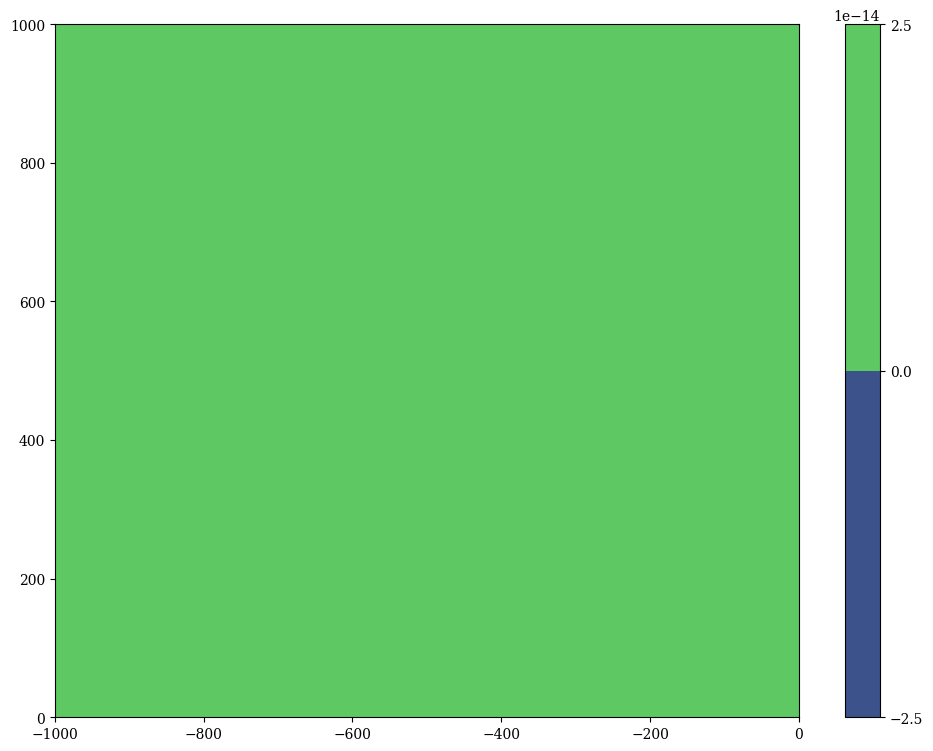

In [16]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 9))
axes = fig.add_subplot(111)
contours = tricontourf(viscoelastic_wave.u_n, axes=axes)
plt.colorbar(contours)

For the comparison between the viscoelastic and the elastic cases, we define another dictionary without the viscoelasticity parameters, and perform the wave propagation as before:

In [9]:
elastic_dictionary = base_dictionary.copy()

In [10]:
elastic_wave = spyro.IsotropicWave(elastic_dictionary)

elastic_wave.set_mesh(input_mesh_parameters={"edge_length": dx_target, "periodic": True})

Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters
Creating firedrake_mesh type mesh.


/home/paulanevesdearaujo/spyro/spyro/solvers/wave.py:166: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Mesh Created with 10000 Nodes and 20000 Area Elements


In [11]:
elastic_wave.forward_solve()


Solving Forward Problem
Saving Displacement in: results/forward_outputsn[0].pvd
Simulation time is:        0.0 seconds
Simulation time is:       0.05 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.15 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.25 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.35 seconds
Simulation time is:        0.4 seconds


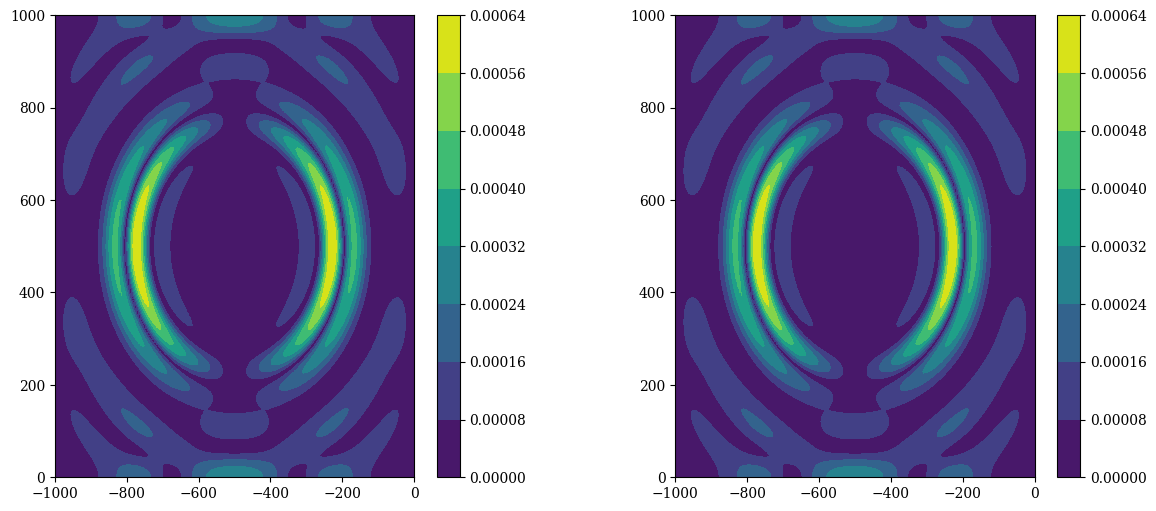

In [12]:
#spyro.plots.plot_function(elastic_wave.u_n)


fig = plt.figure(figsize=(12, 6))

subfigs = fig.subfigures(1, 2, wspace=0.07)

ax0 = subfigs[0].add_subplot(111)
contours = tricontourf(viscoelastic_wave.u_n, axes=ax0)
plt.colorbar(contours)

ax1 = subfigs[1].add_subplot(111)
contours1 = tricontourf(elastic_wave.u_n, axes=ax1)
plt.colorbar(contours1)

plt.show()

Our current code also supports anisotropy. We start with the VTI case and define the following dictionary:

In [20]:
anisotropic_elastic_dictionary = elastic_dictionary.copy()

For this test, we add anisotropy parameters:

In [21]:
anisotropic_elastic_dictionary["wave_type"] = 'anisotropic_VTI'
anisotropic_elastic_dictionary["anisotropy"] = {
    'epsilon':0.3, 
    'gamma': 0.1,
    'delta': 0.15,
    'anisotropy': 'exact'
}

Finally, we perform the elastic wave propagation:

In [22]:
anisotropic_elastic_wave = spyro.IsotropicWave(anisotropic_elastic_dictionary)

anisotropic_elastic_wave.set_mesh(mesh_parameters={"dx": dx_target, "periodic": True})

Parallelism type: automatic


/home/paulanevesdearaujo/spyro-dev/attenuation_isotropic/spyro/io/model_parameters.py:579: UserWarning: No velocity model set initially. If using user defined conditional or expression, please input it in the Wave object.
  warnings.warn(
/home/paulanevesdearaujo/spyro-dev/attenuation_isotropic/spyro/solvers/wave.py:84: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


In [23]:
anisotropic_elastic_wave.forward_solve()

Elastic wave propagation
Saving Displacement in: results/forward_outputsn0.pvd


/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:        0.0 seconds
Simulation time is:       0.05 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.15 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.25 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.35 seconds
Simulation time is:        0.4 seconds


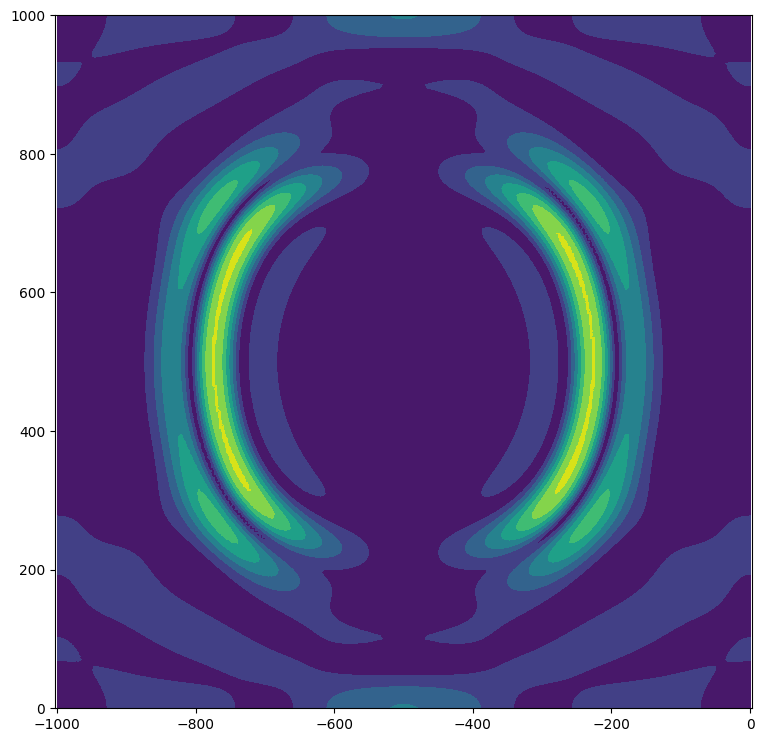

In [24]:
spyro.plots.plot_function(anisotropic_elastic_wave.u_n)

To perform the propagation of viscoelastic waves in anisotropic media, we define the following dictionary:

In [25]:
anisotropic_viscoelastic_dictionary = anisotropic_elastic_dictionary.copy()

And the dictionary already contains the main parameters for anisotropy. We can add attenuation parameters:

In [37]:
anisotropic_viscoelastic_dictionary["viscoelasticity"] = {
    "viscoelastic": True,
    "visco_type": "maxwell_gsls_Q",
    "Q_type": 'file',          # agora usamos funções espaciais
    "branches": L,
    "omega_gsls": omega_relax,
    "y_gsls": y,
    "Qp_inv": 1/Q, 
    "Qs_inv": 1/Q, 
    "Qepsilon_inv": 1/Q, 
    "Qdelta_inv": 1/Q,        
    "Qgamma_inv": 1/Q,         
    "lmbda_s": lmbda,
    "mu_s": mu,
}


Then we run the wave propagation:

In [27]:
anisotropic_viscoelastic_wave = spyro.IsotropicWave(anisotropic_viscoelastic_dictionary)

anisotropic_viscoelastic_wave.set_mesh(mesh_parameters={"dx": dx_target, "periodic": True})

anisotropic_viscoelastic_wave.forward_solve()

Parallelism type: automatic


/home/paulanevesdearaujo/spyro-dev/attenuation_isotropic/spyro/io/model_parameters.py:579: UserWarning: No velocity model set initially. If using user defined conditional or expression, please input it in the Wave object.
  warnings.warn(
/home/paulanevesdearaujo/spyro-dev/attenuation_isotropic/spyro/solvers/wave.py:84: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Viscoelastic Maxwell/GSLS (Q-based) - Voigt notation (generalized C::Gamma)
Saving Displacement in: results/forward_outputsn0.pvd


/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:        0.0 seconds
Simulation time is:       0.05 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.15 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.25 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.35 seconds
Simulation time is:        0.4 seconds


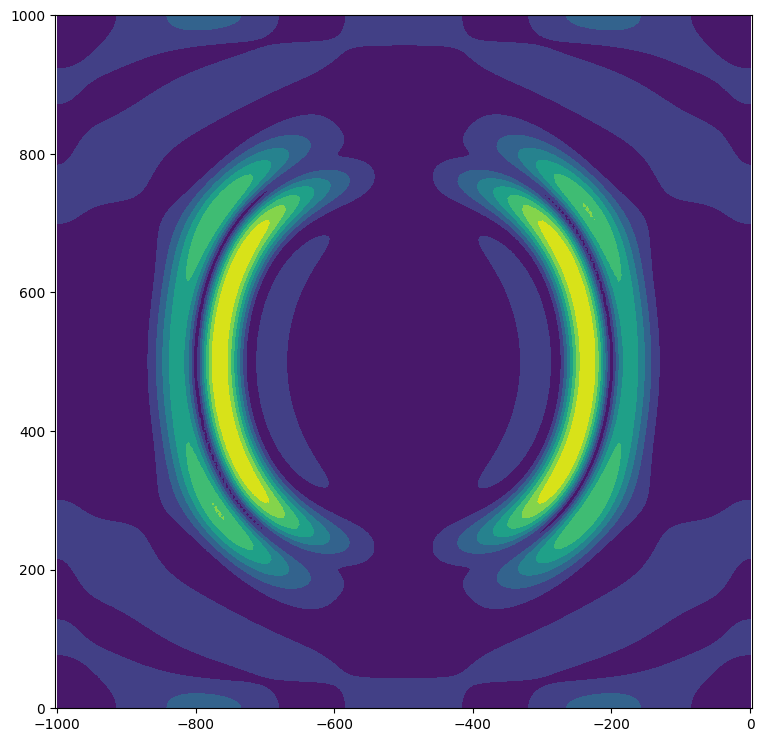

In [28]:
spyro.plots.plot_function(anisotropic_viscoelastic_wave.u_n)

Our code also supports "weak" anisotropy, for which we set "anisotropy" as "weak" instead of "exact". 

Finally, we can also simulate wave propagation in TTI media. We start with the elastic case:

In [29]:
anisotropic_elastic_TTI_dictionary = anisotropic_elastic_dictionary.copy()

For the TTI case, we change the wave type from "anisotropic_VTI" to "anisotropic_TTI" and add the parameters $\theta$ and $\phi$:

In [30]:
anisotropic_elastic_TTI_dictionary["wave_type"] = "anisotropic_TTI"

anisotropic_elastic_TTI_dictionary["anisotropy"]["theta"] = 30.0
anisotropic_elastic_TTI_dictionary["anisotropy"]["phi"] = 0.0

In [31]:
anisotropic_elastic_TTI_wave = spyro.IsotropicWave(anisotropic_elastic_TTI_dictionary)

anisotropic_elastic_TTI_wave.set_mesh(mesh_parameters={"dx": dx_target, "periodic": True})

anisotropic_elastic_TTI_wave.forward_solve()

Parallelism type: automatic


/home/paulanevesdearaujo/spyro-dev/attenuation_isotropic/spyro/io/model_parameters.py:579: UserWarning: No velocity model set initially. If using user defined conditional or expression, please input it in the Wave object.
  warnings.warn(
/home/paulanevesdearaujo/spyro-dev/attenuation_isotropic/spyro/solvers/wave.py:84: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Elastic wave propagation
Saving Displacement in: results/forward_outputsn0.pvd


/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:        0.0 seconds
Simulation time is:       0.05 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.15 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.25 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.35 seconds
Simulation time is:        0.4 seconds


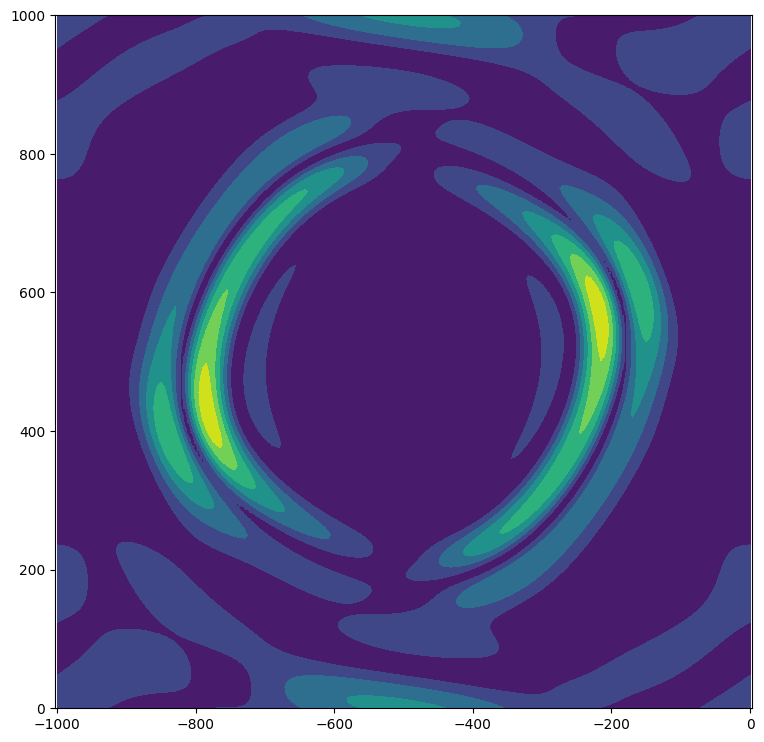

In [32]:
spyro.plots.plot_function(anisotropic_elastic_TTI_wave.u_n)

For the viscoelastic case, we simply copy the previously defined dictionary, and add the viscoelasticity parameters:

In [33]:
anisotropic_viscoelastic_TTI_dictionary = anisotropic_elastic_TTI_dictionary.copy()

anisotropic_viscoelastic_TTI_dictionary["viscoelasticity"] = {
    "viscoelastic": True,
    "visco_type": "maxwell_gsls_Q",
    "Q_type": 'file',          
    "branches": L,
    "omega_gsls": omega_relax,
    "y_gsls": y,
    "Qp_inv": 1/Q,
    "Qs_inv": 1/Q, 
    "Qepsilon_inv": 1/Q, 
    "Qdelta_inv": 1/Q,        
    "Qgamma_inv": 1/Q,        
    "lmbda_s": lmbda,
    "mu_s": mu,
}

In [34]:
anisotropic_viscoelastic_TTI_wave = spyro.IsotropicWave(anisotropic_viscoelastic_TTI_dictionary)

anisotropic_viscoelastic_TTI_wave.set_mesh(mesh_parameters={"dx": dx_target, "periodic": True})

anisotropic_viscoelastic_TTI_wave.forward_solve()

Parallelism type: automatic


/home/paulanevesdearaujo/spyro-dev/attenuation_isotropic/spyro/io/model_parameters.py:579: UserWarning: No velocity model set initially. If using user defined conditional or expression, please input it in the Wave object.
  warnings.warn(
/home/paulanevesdearaujo/spyro-dev/attenuation_isotropic/spyro/solvers/wave.py:84: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Viscoelastic Maxwell/GSLS (Q-based) - Voigt notation (generalized C::Gamma)
Saving Displacement in: results/forward_outputsn0.pvd


/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(
/home/paulanevesdearaujo/venv-firedrake/lib/python3.12/site-packages/ufl/utils/sorting.py:88: UserWarning: Applying str() to a metadata value of type QuadratureRule, don't know if this is safe.
  warnings.warn(


Simulation time is:        0.0 seconds
Simulation time is:       0.05 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.15 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.25 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.35 seconds
Simulation time is:        0.4 seconds


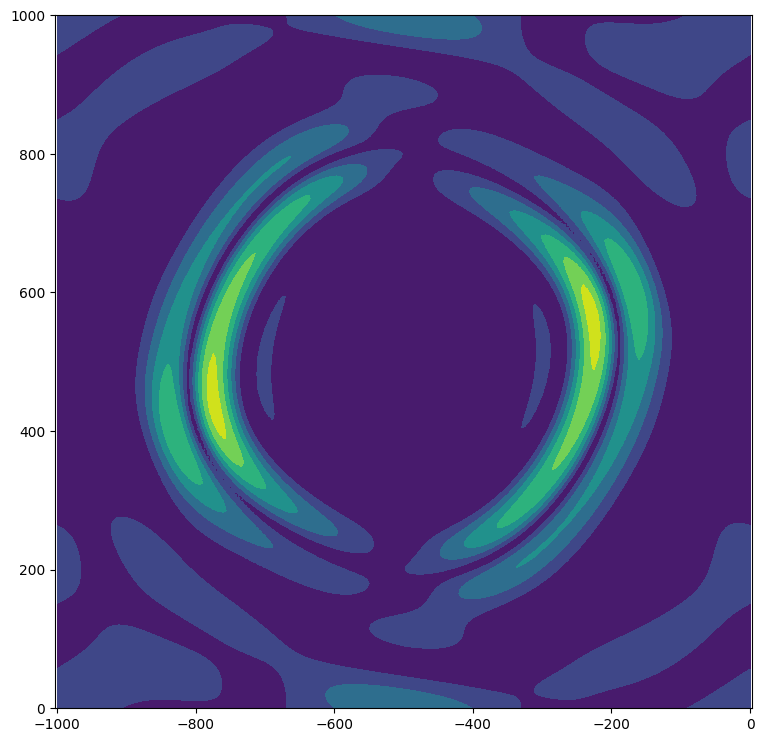

In [35]:
spyro.plots.plot_function(anisotropic_viscoelastic_TTI_wave.u_n)